# A notebook to sanitize SOCOFing original dataset

# Transform all images from given sub directories to 
# 1. (128, 128) size 
# 2. RBG
# 3. jpg

# Save sanitized images to class named subdirectories

In [1]:
# Import librairies
import os
import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

In [2]:
# constants for the original dataset

# True : consider both "Real" and "Altered" subdirectories
# False : consider only "Real" subdirectory (smaller dataset, faster processing)
CONSIDER_FULL_DATASET = False

# Define top-level directory and output CSV path based on the dataset choice
if CONSIDER_FULL_DATASET:
    input_dir = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing"
    output_csv_path = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Full_Organised_with_features.csv"
else:
    input_dir = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing/Real"
    output_csv_path = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Real_Organised_with_features.csv"

In [3]:
# List to store file information and images features in the original dataset
data = []

# Traverse the input directory to get all image files
for dirname, _, filenames in os.walk(input_dir):
    for filename in filenames:

        if filename == ".DS_Store":  # Skip macOS system files
            continue
        
        # Extract the features from the dirname and the filename
        file_path = os.path.join(dirname, filename)
            
        # The individual is the name of the parent directory of the path
        individual = os.path.basename(os.path.dirname(file_path))

        if filename.find("Right") != -1:
            hand = "Right"
        elif filename.find("Left") != -1:
            hand = "Left"
        else:
           hand = None    

        if filename.find("thumb") != -1:
            finger = "thumb"
        elif filename.find("index") != -1:
            finger = "index"
        elif filename.find("middle") != -1:
            finger = "middle"
        elif filename.find("ring") != -1:
            finger = "ring"
        elif filename.find("little") != -1:
            finger = "little"
        else:
            finger = None

        # Extract the image features
        img = Image.open(file_path)
        try:
            img.verify()  # Verify that the file is a valid image
        except:
            print(f"Invalid image file: {file_path}")
            continue
        
        data.append([individual, file_path, img.format, img.size, img.mode, hand, finger])

# Create a DataFrame
df = pd.DataFrame(data, columns=["Individual", "ImagePath", "ImageFormat", "ImageSize", "ImageMode", "Hand", "Finger"])

# Add an index column
df.index.name = "ID"

# Save to CSV
df.to_csv(output_csv_path)

print(f"Full Organised Dataset CSV file with features saved at: {output_csv_path}")

Full Organised Dataset CSV file with features saved at: /Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Real_Organised_with_features.csv


In [4]:
# Display the information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Individual   6000 non-null   str   
 1   ImagePath    6000 non-null   str   
 2   ImageFormat  6000 non-null   str   
 3   ImageSize    6000 non-null   object
 4   ImageMode    6000 non-null   str   
 5   Hand         6000 non-null   str   
 6   Finger       6000 non-null   str   
dtypes: object(1), str(6)
memory usage: 328.3+ KB


In [5]:
# Display the statistical summary of the dataset
df.describe()

,Individual,ImagePath,ImageFormat,ImageSize,ImageMode,Hand,Finger
count,6000,6000,6000,6000,6000,6000,6000
unique,600,6000,1,2,2,2,5
top,114__F,/Users/laurent/Projects/projet-fingerprint-val...,BMP,"(96, 103)",RGBA,Right,index
freq,10,1,6000,5956,5956,3000,1200


In [6]:
# Display the distribution of individual, ImageFormat, ImageSize, ImageMode, hand, and fingers
print(df["Individual"].value_counts())
print(df["ImageFormat"].value_counts())
print(df["ImageSize"].value_counts())
print(df["ImageMode"].value_counts())
print(df["Hand"].value_counts())
print(df["Finger"].value_counts())

Individual
114__F    10
138__M    10
9__M      10
96__M     10
405__M    10
          ..
368__M    10
228__M    10
103__F    10
315__F    10
204__F    10
Name: count, Length: 600, dtype: int64
ImageFormat
BMP    6000
Name: count, dtype: int64
ImageSize
(96, 103)     5956
(241, 298)      44
Name: count, dtype: int64
ImageMode
RGBA    5956
RGB       44
Name: count, dtype: int64
Hand
Right    3000
Left     3000
Name: count, dtype: int64
Finger
index     1200
little    1200
middle    1200
ring      1200
thumb     1200
Name: count, dtype: int64


In [7]:
# show null values
df.isnull().sum()

Individual     0
ImagePath      0
ImageFormat    0
ImageSize      0
ImageMode      0
Hand           0
Finger         0
dtype: int64

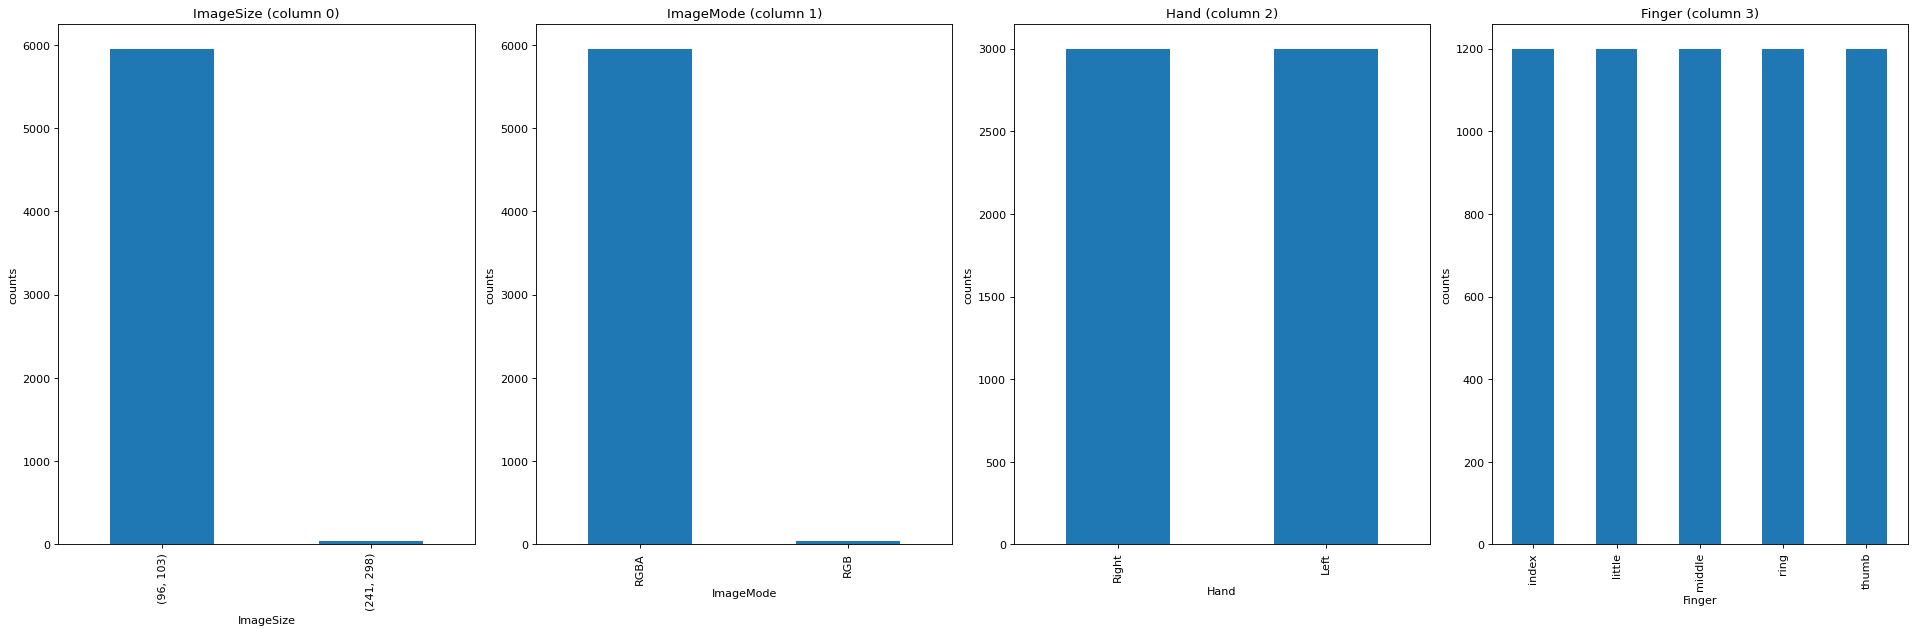

In [8]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = int((nCol + nGraphPerRow - 1) / nGraphPerRow)
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

# show distribution of columns
plotPerColumnDistribution(df, 10, 5)

# Sanitize the images in the dataset

In [ ]:
# Constants

# traget images mode for conversion 
target_image_mode = "RGB" # colored images

# target image size for resizing
target_image_size = (128, 128)

# output format for the sanitized images
target_image_format = "JPEG"

# define the root directory for the sanitized images and the output CSV path based on the dataset choice
if CONSIDER_FULL_DATASET:
    output_sanitized_dir = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Sanitized"
    output_sanitized_csv_path = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Sanitized_with_features.csv"
else:
    output_sanitized_dir = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Real_Sanitized"
    output_sanitized_csv_path = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Real_Sanitized_with_features.csv"

In [36]:
# List to store file information
imgdata = []

# Traverse the input directory to get all image files
for dirname, _, filenames in os.walk(input_dir):
    for filename in filenames:
        
        if filename == ".DS_Store":  # Skip macOS system files
            continue
          
        file_path = os.path.join(dirname, filename)
            
        # Extract finger (label) from the filename
        if filename.find("thumb") != -1:
            finger = "thumb"
        elif filename.find("index") != -1:
            finger = "index"
        elif filename.find("middle") != -1:
            finger = "middle"
        elif filename.find("ring") != -1:
            finger = "ring"
        elif filename.find("little") != -1:
            finger = "little"
        else:
            print(f"Error extracting label from filename: {filename}")
            continue

        # Convert and resize the image
        img = Image.open(file_path)
        try:
            img = img.convert(target_image_mode)  # Convert to target mode
            img = img.resize(target_image_size)  # Resize to target size
        except Exception as e:
            print(f"Error processing image {file_path}: {e}")
            continue

        # Construct a non conlifting filename for the sanitized image
        filename = filename.replace(".BMP", f".{target_image_format.lower()}")
        output_sanitized_filename = os.path.join(output_sanitized_dir, finger, filename)

        while os.path.exists(output_sanitized_filename):
            filename = filename.replace(f".{target_image_format.lower()}", f"_{np.random.randint(1000)}.{target_image_format.lower()}")
            output_sanitized_filename = os.path.join(output_sanitized_dir, finger, filename)

        # save the image
        img.save(output_sanitized_filename, target_image_format)  # Save the sanitized image

        try:
            img = Image.open(output_sanitized_filename)  # Re-open the saved image to get the final features after conversion and resizing
            img.verify()  # Verify that the file is a valid image
        except Exception as e:
            print(f"Error verifying image {output_sanitized_filename}: {e}")
            continue

        imgdata.append([output_sanitized_filename, img.format, img.size, img.mode, finger])

# Create a DataFrame
imgdf = pd.DataFrame(imgdata, columns=["ImagePath", "ImageFormat", "ImageSize", "ImageMode", "Finger"])

# Add an index column
imgdf.index.name = "ID"

# Save to CSV
imgdf.to_csv(output_sanitized_csv_path)

print(f"Sanitized Dataset CSV file with features saved at: {output_sanitized_csv_path}")


Sanitized Dataset CSV file with features saved at: /Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Real_Sanitized_with_features.csv


In [37]:
# Display the information about the dataset
imgdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ImagePath    6000 non-null   str   
 1   ImageFormat  6000 non-null   str   
 2   ImageSize    6000 non-null   object
 3   ImageMode    6000 non-null   str   
 4   Finger       6000 non-null   str   
dtypes: object(1), str(4)
memory usage: 234.5+ KB


In [38]:
# Display the statistical summary of the dataset
imgdf.describe()

,ImagePath,ImageFormat,ImageSize,ImageMode,Finger
count,6000,6000,6000,6000,6000
unique,6000,1,1,1,5
top,/Users/laurent/Projects/projet-fingerprint-val...,JPEG,"(224, 224)",RGB,index
freq,1,6000,6000,6000,1200


In [39]:
# Display the distribution of ImageFormat, ImageSize, ImageMode, and finger (label)
print(imgdf["ImageFormat"].value_counts())
print(imgdf["ImageSize"].value_counts())
print(imgdf["ImageMode"].value_counts())
print(imgdf["Finger"].value_counts())

ImageFormat
JPEG    6000
Name: count, dtype: int64
ImageSize
(224, 224)    6000
Name: count, dtype: int64
ImageMode
RGB    6000
Name: count, dtype: int64
Finger
index     1200
little    1200
middle    1200
ring      1200
thumb     1200
Name: count, dtype: int64


In [40]:
# show null values
imgdf.isnull().sum()

ImagePath      0
ImageFormat    0
ImageSize      0
ImageMode      0
Finger         0
dtype: int64

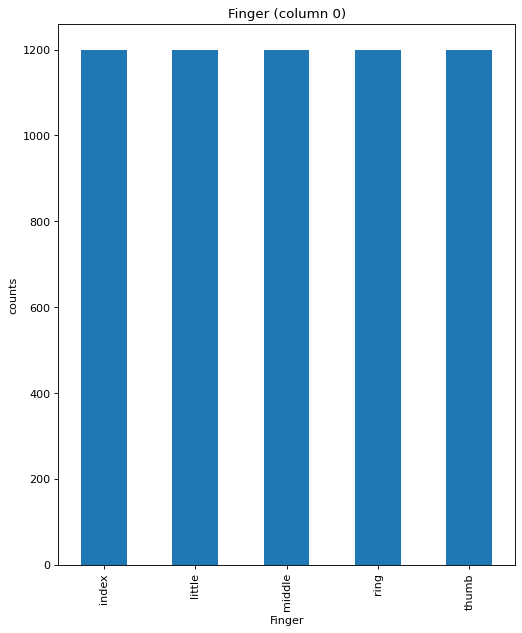

In [41]:
# show distribution of columns
plotPerColumnDistribution(imgdf, 10, 5)

# Verify sanitized dataset 

In [44]:
# constants for the dataset

# Define the directory containing the images and the output CSV path based on the dataset choice
if CONSIDER_FULL_DATASET:
    sanitized_input_dir = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Sanitized"
    final_output_sanitized_csv_path = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Sanitized_with_labels.csv"
else:
    sanitized_input_dir = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Real_Sanitized"
    final_output_sanitized_csv_path = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Real_Sanitized_with_labels.csv"

In [45]:
# List to store file information
sanimgdata = []

# Traverse the input directory to get all image files
for dirname, _, filenames in os.walk(sanitized_input_dir):
    for filename in filenames:

        if filename == ".DS_Store":  # Skip macOS system files
            continue

        # Ensure only image files are considered
        if filename.endswith(".jpeg"):

            file_path = os.path.join(dirname, filename)
            
            # Extract the features from the dirname and the filename

            # The individual is the name of the parent directory of the path
            individual = os.path.basename(os.path.dirname(file_path)) 

            if filename.find("thumb") != -1:
                finger = "thumb"
            elif filename.find("index") != -1:
                finger = "index"
            elif filename.find("middle") != -1:
                finger = "middle"
            elif filename.find("ring") != -1:
                finger = "ring"
            elif filename.find("little") != -1:
                finger = "little"
            else:
                finger = None

            # verify the image
            img = Image.open(file_path)
            try:
                img.verify()  # Verify that the file is a valid image
            except:
                print(f"Invalid image file: {file_path}")
                continue

            sanimgdata.append([file_path, finger])


# Create a DataFrame
sanimgdf = pd.DataFrame(sanimgdata, columns=["ImagePath", "Finger"])

# Add an index column
sanimgdf.index.name = "ID"

# Save to CSV
sanimgdf.to_csv(final_output_sanitized_csv_path)

print(f"Sanitized Dataset CSV file with labels saved at: {final_output_sanitized_csv_path}")

Sanitized Dataset CSV file with labels saved at: /Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Real_Sanitized_with_labels.csv


In [46]:
# Display the information about the dataset
sanimgdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ImagePath  6000 non-null   str  
 1   Finger     6000 non-null   str  
dtypes: str(2)
memory usage: 93.9 KB


In [47]:
# Display statistical summary of the dataset
sanimgdf.describe()

,ImagePath,Finger
count,6000,6000
unique,6000,5
top,/Users/laurent/Projects/projet-fingerprint-val...,little
freq,1,1200


In [48]:
# Display the distribution of fingers
print(sanimgdf["Finger"].value_counts())

Finger
little    1200
middle    1200
thumb     1200
index     1200
ring      1200
Name: count, dtype: int64


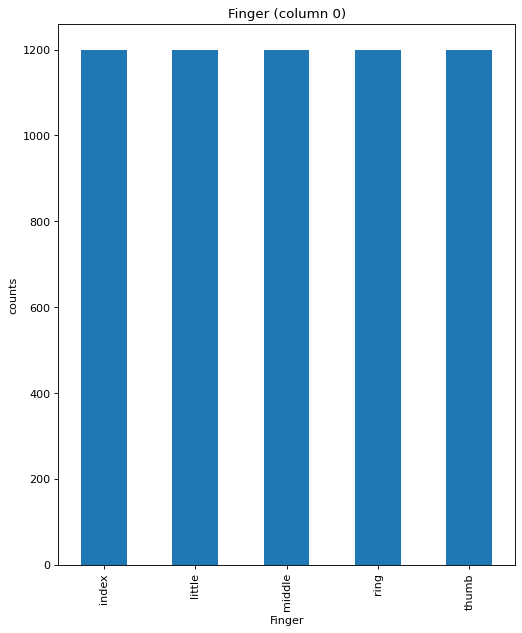

In [49]:
# show distribution of columns
plotPerColumnDistribution(imgdf, 10, 5)

In [50]:
# Display of number of thumbs, index, middle, ring, and little fingers
print(f"Percentage of Thumbs: {sanimgdf['Finger'].value_counts().get('thumb', 0) / len(sanimgdf) * 100:.2f}%")
print(f"Percentage of Index fingers: {sanimgdf['Finger'].value_counts().get('index', 0) / len(sanimgdf) * 100:.2f}%")
print(f"Percentage of Middle fingers: {sanimgdf['Finger'].value_counts().get('middle', 0) / len(sanimgdf) * 100:.2f}%")
print(f"Percentage of Ring fingers: {sanimgdf['Finger'].value_counts().get('ring', 0) / len(sanimgdf) * 100:.2f}%")
print(f"Percentage of Little fingers: {sanimgdf['Finger'].value_counts().get('little', 0) / len(sanimgdf) * 100:.2f}%")

Percentage of Thumbs: 20.00%
Percentage of Index fingers: 20.00%
Percentage of Middle fingers: 20.00%
Percentage of Ring fingers: 20.00%
Percentage of Little fingers: 20.00%
